<a href="https://colab.research.google.com/github/lucaslopesassad-bit/UENF_LucasAssad/blob/main/trabalho_final_parte_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 3.1 — Tabela integrada clima x produção (exploratório)

Nesta seção é construída uma tabela (pandas DataFrame) reunindo, por estação do ano, as médias climáticas sazonais calculadas na Parte 1 (reanálise ERA5 para o domínio do Pará em 2024) e um Índice de produção tratado como campo qualitativo. Esse tratamento qualitativo foi adotado porque o conjunto de imagens usado para treinar/validar o detector de açaí na Parte 2 não possui metadados de data/estação, o que impede calcular uma contagem real de detecções por estação — trata-se, portanto, de um proxy ilustrativo, e não de uma medição empírica de produção.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
estacoes = ['Verao', 'Outono', 'Inverno', 'Primavera']
precipitacao_mm = [0.384, 0.481, 0.059, 0.075]
temperatura_c = [29.23, 29.48, 31.53, 32.26]
umidade_pct = [70.89, 72.21, 53.21, 54.20]
vento_ms = [2.68, 2.32, 3.10, 2.79]
indice_producao = ['Alta', 'Baixa', 'Media', 'Alta']
df_estacoes = pd.DataFrame({'Estacao': estacoes, 'Precipitacao (mm)': precipitacao_mm, 'Temperatura (C)': temperatura_c, 'Umidade (%)': umidade_pct, 'Vento (m/s)': vento_ms, 'Indice de producao (qualitativo)': indice_producao})
df_estacoes

,Estacao,Precipitacao (mm),Temperatura (C),Umidade (%),Vento (m/s),Indice de producao (qualitativo)
0,Verao,0.384,29.23,70.89,2.68,Alta
1,Outono,0.481,29.48,72.21,2.32,Baixa
2,Inverno,0.059,31.53,53.21,3.10,Media
3,Primavera,0.075,32.26,54.20,2.79,Alta


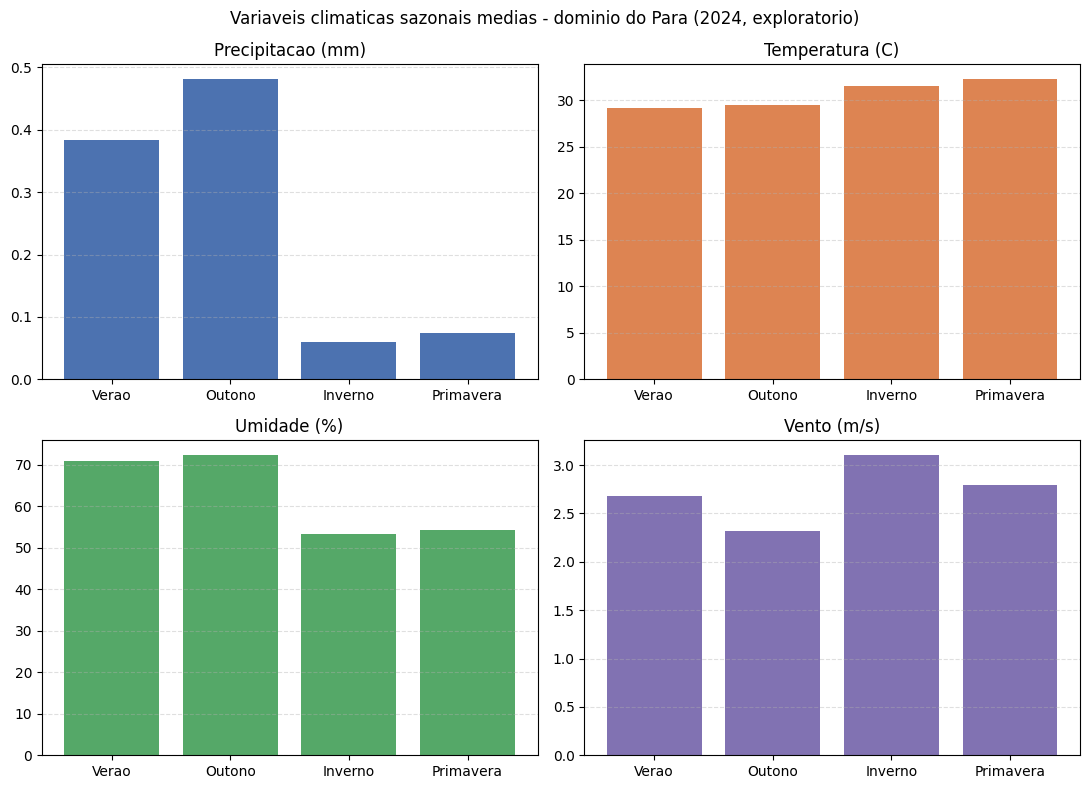

In [ ]:
variaveis_plot = ['Precipitacao (mm)', 'Temperatura (C)', 'Umidade (%)', 'Vento (m/s)']
cores = ['#4C72B0', '#DD8452', '#55A868', '#8172B2']
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes_flat = axes.flatten()
for i in range(4): axes_flat[i].bar(df_estacoes['Estacao'], df_estacoes[variaveis_plot[i]], color=cores[i]); axes_flat[i].set_title(variaveis_plot[i]); axes_flat[i].grid(axis='y', linestyle='--', alpha=0.4)
fig.suptitle('Variaveis climaticas sazonais medias - dominio do Para (2024, exploratorio)')
plt.tight_layout()
plt.show()

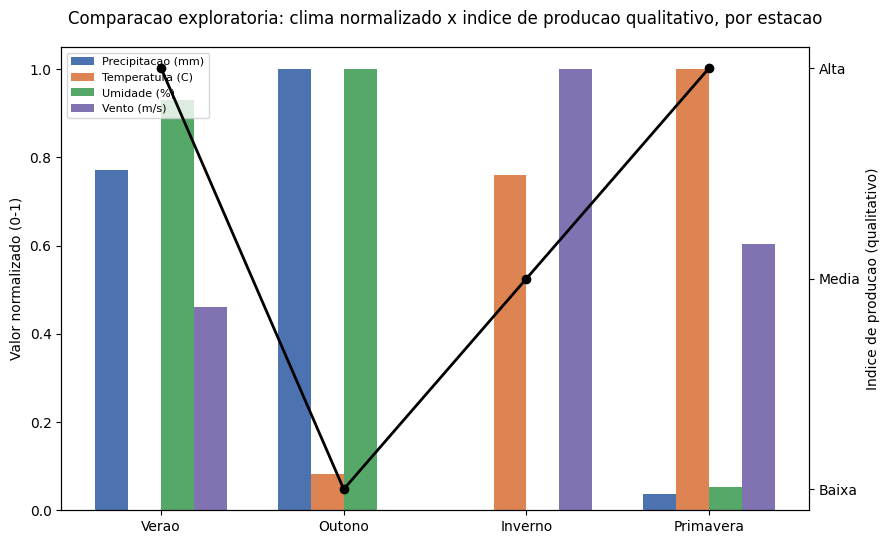

In [ ]:
mapa_indice = {'Baixa': 1, 'Media': 2, 'Alta': 3}
indice_numerico = df_estacoes['Indice de producao (qualitativo)'].map(mapa_indice)
df_norm = df_estacoes[variaveis_plot].apply(lambda col: (col - col.min()) / (col.max() - col.min()))
x = np.arange(len(df_estacoes))
largura = 0.18
fig, ax1 = plt.subplots(figsize=(9, 5.5))
for i in range(4): ax1.bar(x + i*largura, df_norm[variaveis_plot[i]], width=largura, label=variaveis_plot[i], color=cores[i])
ax1.set_xticks(x + largura*1.5)
ax1.set_xticklabels(df_estacoes['Estacao'])
ax1.set_ylabel('Valor normalizado (0-1)')
ax1.legend(loc='upper left', fontsize=8)
ax2 = ax1.twinx()
ax2.plot(x + largura*1.5, indice_numerico, color='black', marker='o', linewidth=2, label='Indice de producao (qualitativo)')
ax2.set_yticks([1, 2, 3])
ax2.set_yticklabels(['Baixa', 'Media', 'Alta'])
ax2.set_ylabel('Indice de producao (qualitativo)')
fig.suptitle('Comparacao exploratoria: clima normalizado x indice de producao qualitativo, por estacao')
plt.tight_layout()
plt.show()

### Discussão (Parte 3.1)

A tabela e os gráficos acima têm caráter estritamente exploratório. As médias de precipitação, temperatura, umidade e vento correspondem a estimativas de reanálise (ERA5) para o domínio do Pará em 2024, sujeitas às limitações espaciais e temporais discutidas na Parte 1. O Índice de produção foi mantido como um campo qualitativo (Baixa/Média/Alta) e não como uma contagem real de detecções de acai_cacho por estação, já que o dataset de imagens usado no treinamento do detector (Parte 2) não possui metadados de data ou sazonalidade — logo, qualquer tentativa de contar detecções "por estação" seria artificial e não representaria produção real de açaí ao longo do ano.

Reforça-se, conforme exigido pelo enunciado, que nenhuma relação de causa e efeito deve ser inferida a partir dessas comparações. As variações visuais entre estações (por exemplo, temperaturas mais altas no Inverno/Primavera do domínio ERA5, ou umidade mais alta no Outono/Verão) não permitem concluir que o clima determina a produção de açaí ou a presença do barbeiro (vetor da doença de Chagas). Trata-se apenas de uma justaposição descritiva de indicadores, útil para gerar hipóteses a serem testadas com dados de campo reais (séries temporais de produção e monitoramento entomológico), e não de uma análise causal ou inferencial.